In [11]:
from solver import *
from consts import *
from genetic_algo import fitness_function

In [12]:
from pathlib import Path
import aerosandbox as asb


# Lista dostępnych profilów (załadowana raz na starcie)
def load_airfoils(folder):
    files = list(folder.glob("*.dat"))
    return {i: asb.Airfoil(name=f.stem, coordinates=f) for i, f in enumerate(files)}

AIRFOIL_DATABASE = load_airfoils(AIRFOIL_FOLDER)
AIRFOIL_DATABASE

{0: Airfoil AG25-il (160 points),
 1: Airfoil AG35 (180 points),
 2: Airfoil AG36 (180 points),
 3: Airfoil AH 79-100 A (97 points),
 4: Airfoil bumblebee fuselage 134 (157 points),
 5: Airfoil BumbleBee fuselage 178 (157 points),
 6: Airfoil FX 60-100 (97 points),
 7: Airfoil GOE 444 (33 points),
 8: Airfoil NACA-0009 smoothed (69 points),
 9: Airfoil RG-15 8.9% (62 points),
 10: Airfoil Roncz Marske-7 low drag flw (71 points),
 11: Airfoil S7012 8.75% (81 points),
 12: Airfoil SD8020-010-88 (61 points)}

In [13]:
asb.__version__

'4.2.9'

In [14]:
print(AIRFOIL_DATABASE)
print("Rozpiętość: ", B)
print("Prędkość przelotowa: ", TARGET_VELOCITY, "m/s")
print("Masa elektroniki i baterii: ", FIXED_MASS, "kg")
print("Gęstość struktury skrzydła: ", WING_DENSITY, "kg/m2")

{0: Airfoil AG25-il (160 points), 1: Airfoil AG35 (180 points), 2: Airfoil AG36 (180 points), 3: Airfoil AH 79-100 A (97 points), 4: Airfoil bumblebee fuselage 134 (157 points), 5: Airfoil BumbleBee fuselage 178 (157 points), 6: Airfoil FX 60-100 (97 points), 7: Airfoil GOE 444 (33 points), 8: Airfoil NACA-0009 smoothed (69 points), 9: Airfoil RG-15 8.9% (62 points), 10: Airfoil Roncz Marske-7 low drag flw (71 points), 11: Airfoil S7012 8.75% (81 points), 12: Airfoil SD8020-010-88 (61 points)}
Rozpiętość:  1.2
Prędkość przelotowa:  20.0 m/s
Masa elektroniki i baterii:  0.4 kg
Gęstość struktury skrzydła:  2 kg/m2


In [36]:
test_genes ={
        "y_root": 0.06,
        "y_break1_f": 0.40107692362953856,
        "y_break2_f": 0.4487053500599476,
        "y_tip_f": 0.910510052535605,
        "c_root": 0.3474829667659294,
        "c_brk1": 0.15,
        "c_brk2": 0.15,
        "c_tip": 0.04,
        "t_root": -0.2700969584925863,
        "t_brk1": 1.9078294600069654,
        "t_brk2": -1.393185682264143,
        "t_tip": -4.844387335037291,
        "x_root": 0.0,
        "x_brk1": 0.1198170309946362,
        "x_brk2": 0.23987352221233127,
        "x_tip": 0.42634383965530387,
        "z_root": 0.0,
        "z_brk1": 0.0,
        "z_brk2": 0.0,
        "z_tip": 0.0,
        "winglet_target_angle": 89.85229473332441,
        "h_w": 0.15,
        "R_w": 0.08751480550835225,
        "c_w_end": 0.04,
        "sweep_w": 0.1,
        "toe": 0.3645147983509814,
        "id_root": 4.678865254383291,
        "id_brk1": 10.63714388331626,
        "id_brk2": 1.2243630719134657,
        "id_tip": 4.382827183603557,
        "id_w": 6.048536776103584 
}

airplane, mass = build_airplane_curved(test_genes, 'quadratic')
#score, details = fitness_function(test_genes)
print(f"Samolot zbudowany pomyślnie! Szacowana masa: {mass:.3f} kg")
airplane.draw(backend='plotly')
alphas = np.linspace(-5, 15, 30)
x_cg = get_cg(airplane, sm=0.1)
data, x_cg_target = GA_aerodynamics(airplane, TARGET_VELOCITY, alphas, xyz_ref_orig=[x_cg, 0, 0])
score, score_details = fitness_function_weighted(data)
print(f"Score: {score:.2f}")
print(data)
s = str(x_cg_target)
print(f"Środek ciężkości: {s} m")



Samolot zbudowany pomyślnie! Szacowana masa: 0.876 kg


Score: 29.70
{'ld': np.float64(18.451467539767496), 'cl': np.float64(0.4581687746597397), 'cd': np.float64(0.024831020821095787), 'cm_cg': 0.0, 'cma': np.float64(-0.34235588081498103), 'cnb': np.float64(0.021274452580869997), 'oswald': np.float64(0.859789994478018), 'cmq': np.float64(-2.11830145408587), 'clp': np.float64(-0.37353192847959393), 'cnr': np.float64(-0.010117345674797794), 'alpha': np.float64(3.9665172413793113), 'alpha_in_range': np.True_, 'trim_fallback': False, 'mass': np.float64(0.47644871861195465), 'x_np': np.float64(0.20343485701435382), 'x_cg': array([0.18684029]), 'x_cg_ref': array([0.18684029])}
Środek ciężkości: [0.18684029] m


In [26]:
results = analyze_aerodynamics(airplane, mass, TARGET_VELOCITY)
print(results)



{'ld': np.float64(14.855360321358635), 'sm': 0.08, 'cnb': np.float64(0.06350854239963045), 'cl': np.float64(0.2796161354919663), 'cd': np.float64(0.01882257511384236), 'cm_cg': np.float64(0.019349611023565666), 'mass': np.float64(0.8845413210673307), 'x_np': array([0.20013677]), 'x_cg': array([0.18215684]), 'obj': AeroBuildup(
	airplane=Airplane 'Untitled' (1 wing, 0 fuselages)
	op_point=OperatingPoint instance:
	State variables:
		atmosphere: Atmosphere (altitude: 0 m (0 ft), method: 'differentiable')                                                             
		  velocity: 20.0                                                                                                                    
		     alpha: 2.0                                                                                                                     
		      beta: 1.0                                                                                                                     
		         p: 0.0         

In [27]:
metrics = calculate_extra_metrics(airplane, mass, TARGET_VELOCITY)
print(f"--- GEOMETRIA ---")
print(f"Powierzchnia: {metrics['S [m^2]']:.3f} m2")
print(f"Rozpiętość: {metrics['Span']:.3f} m")
print(f"Aerodynamic Center: {metrics['Aerodynamic center']}")
print(f"Neutral Point: ", results['x_np'])
print(f"AR: {metrics['AR']:.2f} (Efektywne: {metrics['AR_eff']:.2f})")
print(f"Taper Ratio: {metrics['Taper']:.2f}")
print(f"Oswald efficiency: {metrics['e']:.3f}")
print(f"Obciążenie: {metrics['Wing Loading [kg/m^2]']:.2f} kg/m2")
print(f"Re: {metrics['Re']:.0f}")
print(f"Mean Twist Angle: {metrics['MtA']:.2f} deg")
print(f"Mean Sweep Angle: {metrics['MsA']:.2f} deg")
print(f"Mean Dihedral Angle: {metrics['MdA']:.2f} deg")

--- GEOMETRIA ---
Powierzchnia: 0.242 m2
Rozpiętość: 1.438 m
Aerodynamic Center: [0.18112732 0.         0.00264053]
Neutral Point:  [0.20013677]
AR: 8.54 (Efektywne: 8.54)
Taper Ratio: 0.26
Oswald efficiency: 0.752
Obciążenie: 3.65 kg/m2
Re: 304218
Mean Twist Angle: -0.33 deg
Mean Sweep Angle: 34.34 deg
Mean Dihedral Angle: 7.45 deg


In [18]:
'''alphas = np.linspace(-5, 12, 30)

basic_aoa = basic_analysis(
    airplane=airplane,
    velocity=18,
    alphas=alphas
)'''

'alphas = np.linspace(-5, 12, 30)\n\nbasic_aoa = basic_analysis(\n    airplane=airplane,\n    velocity=18,\n    alphas=alphas\n)'

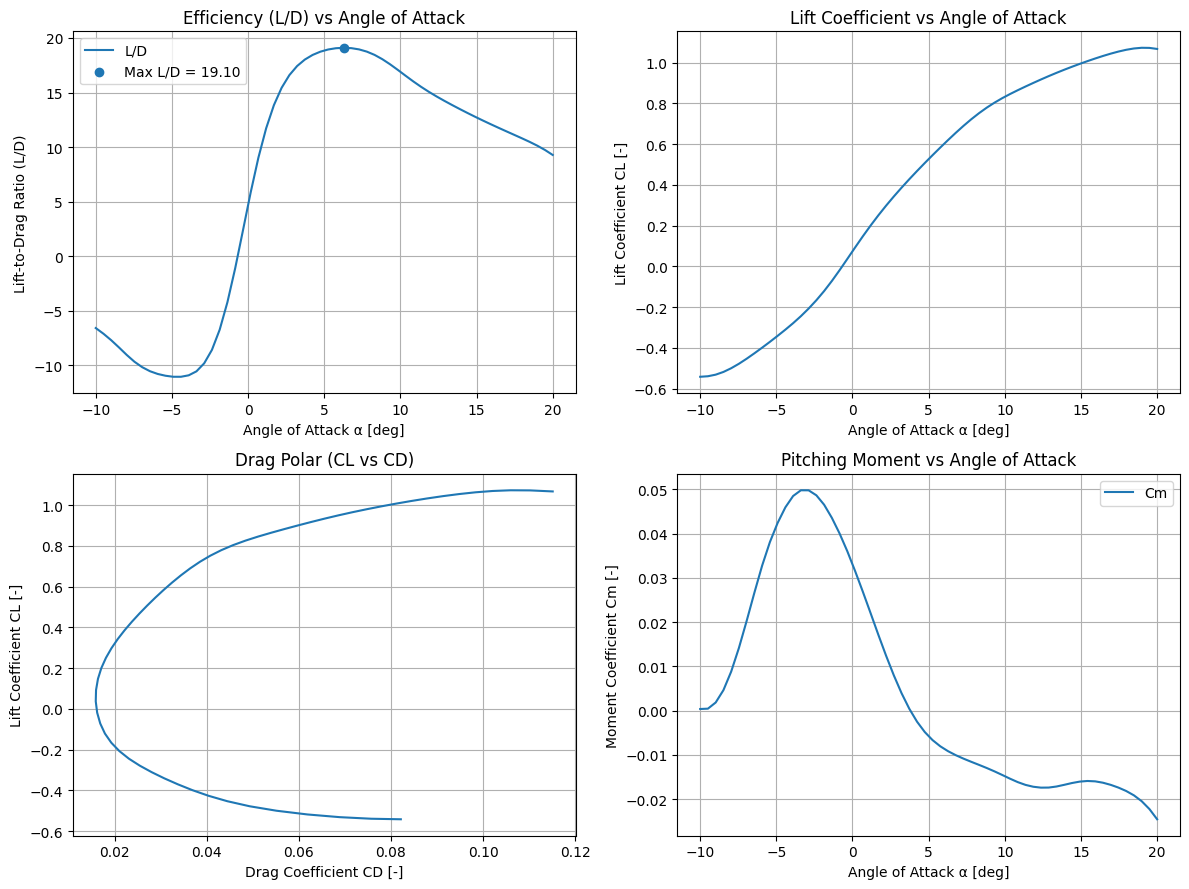


=== SUMMARY ===
Max L/D       : 19.10 at α = 6.27 deg
Oswald e      : 0.772


{'F_g': [array([ -0.77933001,  -0.84051356,  -0.88365637,  -0.89773064,
          -0.86691244,  -0.77644675,  -0.63117068,  -0.45485468,
          -0.26649174,  -0.08170517,   0.0892083 ,   0.24516053,
           0.38543818,   0.51258873,   0.63027608,   0.73664293,
           0.82900822,   0.90183595,   0.94661631,   0.95750297,
           0.93195623,   0.86903625,   0.76957204,   0.63479001,
           0.46554336,   0.2624074 ,   0.02541351,  -0.24577903,
          -0.55138125,  -0.89118653,  -1.26451836,  -1.67015123,
          -2.10603308,  -2.56878448,  -3.05309757,  -3.55150354,
          -4.05536297,  -4.55725126,  -5.05297206,  -5.54188655,
          -6.02706395,  -6.51477091,  -7.01119613,  -7.51932152,
          -8.0388873 ,  -8.5675782 ,  -9.1022646 ,  -9.64061384,
         -10.18163789, -10.7248263 , -11.26947938, -11.81436646,
         -12.35703702, -12.89324356, -13.41646348, -13.9167061 ,
         -14.37828317, -14.77709485, -15.08039142, -15.25496273]),
  array([0., 0.,

In [35]:
alphaSweep = analyze_alpha_sweep_and_plot(airplane, TARGET_VELOCITY, np.linspace(-10, 20, 60), [x_cg_target, 0 ,0])
alphaSweep['raw_result']


In [29]:
print(alphaSweep['raw_result']['wing_aero_components'][0].oswalds_efficiency)
print(f"keys: {list(alphaSweep['raw_result'].keys())}")
res = alphaSweep['raw_result']
print(f"Neutral point: {res['x_np']}")
print(alphaSweep['raw_result']['wing_aero_components'][0].keys())
print(f"center of gravity: {res['x_cg']}")
#alphaSweep['raw_result']['Clb']

0.8188324532879485
keys: ['F_g', 'M_g', 'F_b', 'F_w', 'M_b', 'M_w', 'L', 'Y', 'D', 'l_b', 'm_b', 'n_b', 'CL', 'CY', 'CD', 'Cl', 'Cm', 'Cn', 'wing_aero_components', 'fuselage_aero_components', 'D_profile', 'D_induced', 'CLa', 'CDa', 'CYa', 'Cla', 'Cma', 'Cna', 'x_np', 'CLb', 'CDb', 'CYb', 'Clb', 'Cmb', 'Cnb', 'x_np_lateral', 'CLp', 'CDp', 'CYp', 'Clp', 'Cmp', 'Cnp', 'CLq', 'CDq', 'CYq', 'Clq', 'Cmq', 'Cnq', 'CLr', 'CDr', 'CYr', 'Clr', 'Cmr', 'Cnr']
Neutral point: [0.64346647 0.14596856 0.13354576 0.12851274 0.1243424  0.1222786
 0.12303396 0.12544071 0.13152293 0.14074147 0.14846615 0.1553773
 0.16447346 0.17397678 0.18130513 0.18644962 0.19016375 0.19222487
 0.19343995 0.19495128 0.19638196 0.19771695 0.19922904 0.20012206
 0.20021362 0.19955323 0.19797622 0.19558206 0.19270708 0.18980392
 0.18727369 0.18532559 0.18399323 0.18320306 0.18284854 0.18287475
 0.18332105 0.1842328  0.18549559 0.18676873 0.18738891 0.18660234
 0.18449208 0.18189879 0.17913253 0.17601732 0.17314708 0.17164289

AttributeError: 'AeroComponentResults' object has no attribute 'keys'

In [30]:
alphaSweep['raw_result']['x_np']

array([0.64346647, 0.14596856, 0.13354576, 0.12851274, 0.1243424 ,
       0.1222786 , 0.12303396, 0.12544071, 0.13152293, 0.14074147,
       0.14846615, 0.1553773 , 0.16447346, 0.17397678, 0.18130513,
       0.18644962, 0.19016375, 0.19222487, 0.19343995, 0.19495128,
       0.19638196, 0.19771695, 0.19922904, 0.20012206, 0.20021362,
       0.19955323, 0.19797622, 0.19558206, 0.19270708, 0.18980392,
       0.18727369, 0.18532559, 0.18399323, 0.18320306, 0.18284854,
       0.18287475, 0.18332105, 0.1842328 , 0.18549559, 0.18676873,
       0.18738891, 0.18660234, 0.18449208, 0.18189879, 0.17913253,
       0.17601732, 0.17314708, 0.17164289, 0.17192381, 0.17387504,
       0.17729071, 0.18143191, 0.18543841, 0.18927629, 0.1940648 ,
       0.20300327, 0.22763572, 0.39594618, 0.01451179, 0.09948916])

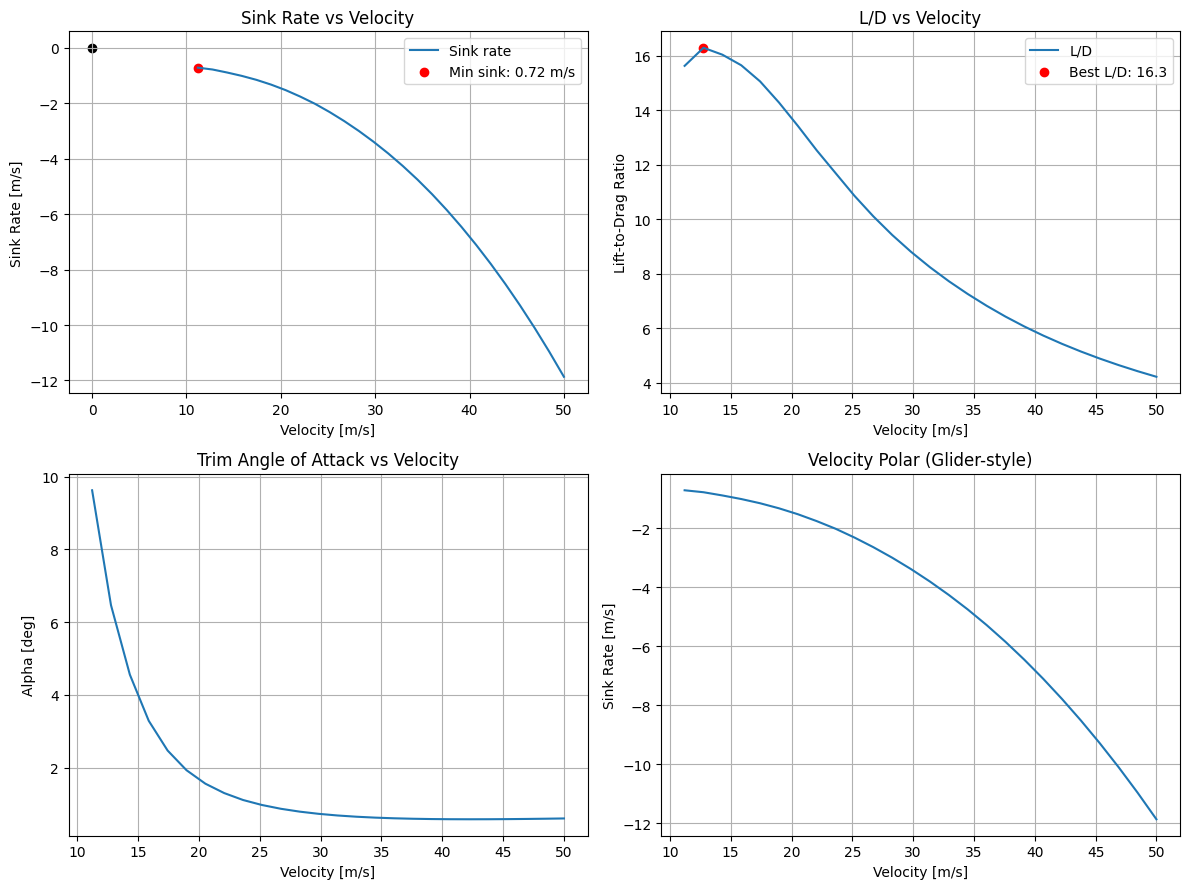


=== VELOCITY POLAR SUMMARY ===
Min sink speed   : 11.21 m/s
Min sink rate    : 0.72 m/s
Best glide speed : 12.76 m/s
Max L/D          : 16.29


In [33]:
import numpy as np
velocities = np.linspace(5, 50, 30)

polar = analyze_velocity_polar(
    airplane=airplane,
    mass=1.5,
    velocities=velocities,
    alpha_range=np.linspace(-5, 20, 50)
)

In [34]:
op = asb.OperatingPoint(velocity=TARGET_VELOCITY, alpha=2)
ab = asb.AeroBuildup(  # This sets up the analysis, but doesn't execute calculation
    airplane=airplane,  # type: asb.Airplane
    op_point=op,  # type: asb.OperatingPoint
    xyz_ref=[results['x_cg'], 0, 0],  # Moment reference and center of rotation.
)
aero = ab.run()  # This executes the actual aero analysis.
aero_with_stability_derivs = ab.run_with_stability_derivatives() 